In [16]:
import pandas as pd
import pysam
import os

# Phylogenetic Order

In [17]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [18]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [19]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [20]:
goodRBMYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/RBMY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodRBMYSamples.append(line.strip())
print(len(goodRBMYSamples))

126


# Pull Sequences

In [21]:
originalDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes_noDbGaP.csv").drop(columns=['Unnamed: 0'])
tspyDF=originalDF[(originalDF['geneName']=='RBMY1B') & (originalDF['geneCompletenessInfo']=='Full_Exon_Copy')].copy()

In [22]:
import json
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Sequence_Network_Colors.json', 'r') as file:
    ColorDictionary = json.load(file)

In [23]:
from Bio.Seq import Seq

In [24]:
#this code pulls the full gene plus/minus 1000 bases on the flanks
uniqueSequences={}
uniquePromoters={}
uniquePromoters2={}
folderDirectory='/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/'
for sample in set(tspyDF['sampleName']):

    geneDF = tspyDF[tspyDF['sampleName']==sample].copy()

    #with open(folderDirectory+"HPRC-HGSVC3-CEPH_v2_TSPY_genes.fasta", 'a+') as file:
    for row in geneDF.index:

        mySeqRealName = str(geneDF.at[row,'contig'])+":"+str(int(geneDF.at[row,'contigStart']))+"-"+str(int(geneDF.at[row,'contigEnd']))
        if mySeqRealName in ColorDictionary.keys():
            
            if ColorDictionary[mySeqRealName][1] == 'black':
                continue
            else:
                mySeqName = str(geneDF.at[row,'contig'])+":"+str(int(geneDF.at[row,'contigStart'])-1000)+"-"+str(int(geneDF.at[row,'contigEnd'])+1000)
        
                sequence1 = ''.join(pysam.faidx(assemblyDict[sample], mySeqName).split()[1:])
                if geneDF.at[row,'orientation'] == '+':
                    sequence = sequence1
                    promoterSequence=sequence[:1000]
                else:
                    sequence = str(Seq(sequence1).reverse_complement())
                    promoterSequence=sequence[:1000]
        
                if str(geneDF.at[row,'geneCompletenessInfo'])=='Full_Exon_Copy':
    
                    uniquePromoters2[mySeqRealName]=promoterSequence
                    
                    if sequence in uniqueSequences:
                        uniqueSequences[sequence].append(mySeqRealName)
            
                    else:
                        uniqueSequences[sequence]=[mySeqRealName]
            
            
                    if promoterSequence in uniquePromoters:
                        uniquePromoters[promoterSequence].append(mySeqRealName)
            
                    else:
                        uniquePromoters[promoterSequence]=[mySeqRealName]
                    
                    
                #if str(geneDF.at[row,'geneCompletenessInfo'])=='Full_Exon_Copy':
                #    file.write(">"+mySeqName+"\n")
                #    file.write(sequence+"\n")
    
        #file.close()

In [25]:
print(len(uniqueSequences))

558


In [26]:
print(len(uniquePromoters))

18


In [28]:
count=1
uniquePromotersNames={}
for x in uniquePromoters.keys():
    uniquePromotersNames[x] = 'SeqPromoter:'+str(count)
    count+=1

In [29]:
from pyjaspar import jaspardb

In [30]:
import re
import pyjaspar
from Bio.Seq import Seq

EXACT_MODE = "iupac"  
IUPAC_REGEX = {
    "A":"A", "C":"C", "G":"G", "T":"T",
    "R":"[AG]", "Y":"[CT]", "S":"[GC]", "W":"[AT]",
    "K":"[GT]", "M":"[AC]", "B":"[CGT]", "D":"[AGT]",
    "H":"[ACT]", "V":"[ACG]", "N":"[ACGT]"
}

JASPAR = jaspardb(release="JASPAR2024")
motifs_list = JASPAR.fetch_motifs(collection="CORE", tax_group="vertebrates")

names2={}

motif_specs = []
for mot in motifs_list:
    motif_id   = mot.matrix_id or mot.name
    motif_name = mot.name
    strict     = str(mot.consensus).upper()
    iupac      = str(mot.degenerate_consensus).upper()
    mlen       = len(strict)
    names2[mot.matrix_id]=mot.name

    if EXACT_MODE == "strict":
        patt_str = strict
        patt_rc  = str(Seq(strict).reverse_complement())
        rx_fwd   = re.compile(re.escape(patt_str))
        rx_rc    = re.compile(re.escape(patt_rc))
    else:
        def iupac_to_regex(s):
            return "".join(IUPAC_REGEX.get(ch, ch) for ch in s)
        patt_str = iupac_to_regex(iupac)
        iupac_rc = str(Seq(iupac).reverse_complement())
        patt_rc  = iupac_to_regex(iupac_rc)
        rx_fwd   = re.compile(patt_str)
        rx_rc    = re.compile(patt_rc)

    motif_specs.append({
        "motif_id": motif_id,
        "motif_name": motif_name,
        "strict": strict,
        "iupac": iupac,
        "mlen": mlen,
        "rx_fwd": rx_fwd,
        "rx_rc": rx_rc
    })

promoters = {x: {'plus': [], 'minus': []} for x in uniquePromotersNames.values()}

for rec in uniquePromoters.keys():
    seq = str(Seq(rec).upper())
    L   = len(seq)
    rc  = str(Seq(seq).reverse_complement())
    pname = uniquePromotersNames[rec]

    for spec in motif_specs:
        mlen = spec["mlen"]
        for m in spec["rx_fwd"].finditer(seq):
            pos = m.start()
            match_seq = seq[pos:pos+mlen]
            promoters[pname]['plus'].append([
                pos, pos+mlen, "+",
                spec["motif_name"], spec["motif_id"],
                None,                       # no score in exact mode
                match_seq,
                spec["iupac"] if EXACT_MODE == "iupac" else spec["strict"]
            ])

        for m in spec["rx_rc"].finditer(rc):
            rc_pos = m.start()
            start  = L - (rc_pos + mlen)
            end    = start + mlen
            match_seq = rc[rc_pos:rc_pos+mlen]   # in motif orientation
            promoters[pname]['minus'].append([
                start, end, "-",
                spec["motif_name"], spec["motif_id"],
                None,
                match_seq,
                spec["iupac"] if EXACT_MODE == "iupac" else spec["strict"]
            ])


In [31]:
import json
#with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_hits.json', 'w') as fp:
#    json.dump(promoters, fp)

In [32]:
rows = [
    (prom, h[3])
    for prom, orient_dict in promoters.items()
    for hits in orient_dict.values()
    for h in hits
]
df = pd.DataFrame(rows, columns=["promoter", "motif"])

countDF = (
    pd.crosstab(df["promoter"], df["motif"])
      .reindex(index=promoters.keys(), fill_value=0)
      .reindex(columns=list(set(list(names2.values()))), fill_value=0)
      .astype("int32")
)

In [33]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (9). Possibly due to duplicate point

Model selection (KMeans sweep):
    silhouette  calinski_harabasz  davies_bouldin
k                                               
2    0.956402       2.448485e+02        0.095008
4    0.888889       1.775612e+32        0.000000
3    0.855066       2.390833e+02        0.130553
5    0.333333       1.851904e+32        0.000000
6    0.333333       1.851904e+32        0.000000
7    0.333333       1.851904e+32        0.000000
8    0.333333       1.851904e+32        0.000000
9    0.333333       1.851904e+32        0.000000

Evaluation:
          method  silhouette  calinski_harabasz  davies_bouldin
0   KMeans(k=2)    0.956402         244.848485        0.095008
1  AggWard(k=2)    0.956402         244.848485        0.095008
cluster
0    12
1     6
Name: count, dtype: int64

Cluster 0 top motifs (lift vs global):
motif
ARNT::HIF1A    1.5
MYCN           1.5
MAX            1.5
Creb3l2        1.5
Mlxip          1.5
MNT            1.5
Arnt           1.5
KLF12          1.0
TFAP4::ETV1    1.0
NR3C1  

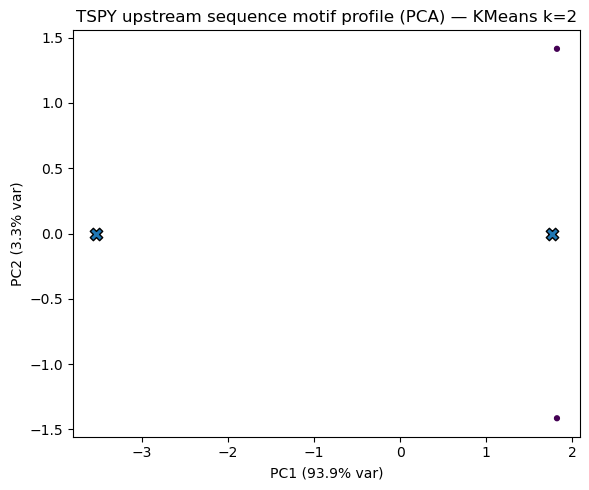

In [34]:
import numpy as np
import pandas as pd

X = countDF.loc[:, (countDF.sum(axis=0) > 0)].copy()
X_tfidf=X.copy()

from sklearn.decomposition import PCA
n_comp = min(50, X_tfidf.shape[1], max(2, X_tfidf.shape[0]-1))  # ensure ≥2
pca = PCA(n_components=n_comp, random_state=1)
X_pca = pca.fit_transform(X_tfidf)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def try_kmeans(X_in, k_list=(2,3,4,5,6,7,8)):
    rows, models = [], {}
    for k in k_list:
        km = KMeans(n_clusters=k, n_init='auto', random_state=1)
        labels = km.fit_predict(X_in)
        s  = silhouette_score(X_in, labels, metric='cosine')
        ch = calinski_harabasz_score(X_in, labels)
        db = davies_bouldin_score(X_in, labels)
        rows.append((k, s, ch, db))
        models[k] = (km, labels)
    return pd.DataFrame(rows, columns=['k','silhouette','calinski_harabasz','davies_bouldin']).set_index('k'), models

km_scores, km_models = try_kmeans(X_pca, k_list=range(2, 10))
best_k = km_scores['silhouette'].idxmax()
best_k=2
km, km_labels = km_models[best_k]

agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_pca)

def metrics_table(X_in, labels, name):
    return pd.DataFrame({
        'method':[name],
        'silhouette':[silhouette_score(X_in, labels, metric='cosine')],
        'calinski_harabasz':[calinski_harabasz_score(X_in, labels)],
        'davies_bouldin':[davies_bouldin_score(X_in, labels)]
    })

eval_df = pd.concat([
    metrics_table(X_pca, km_labels, f'KMeans(k={best_k})'),
    metrics_table(X_pca, agg_labels, f'AggWard(k={best_k})'),
], ignore_index=True)

print("Model selection (KMeans sweep):\n", km_scores.sort_values('silhouette', ascending=False))
print("\nEvaluation:\n", eval_df)

res = countDF.copy()
res['cluster'] = km_labels
print(res['cluster'].value_counts())

def top_motifs_by_cluster(counts: pd.DataFrame, labels: np.ndarray, topn=10):
    df = counts.copy()
    df['cluster'] = labels
    grp_mean = df.groupby('cluster').mean(numeric_only=True)
    global_mean = df.drop(columns=['cluster']).mean(axis=0)
    lift = (grp_mean + 1e-9).divide(global_mean + 1e-9)
    tops = {c: lift.loc[c].sort_values(ascending=False).head(topn) for c in grp_mean.index}
    return tops

tops = top_motifs_by_cluster(countDF, km_labels, topn=10)
for c, s in tops.items():
    print(f"\nCluster {c} top motifs (lift vs global):")
    print(s.round(3))

import matplotlib.pyplot as plt

PC = X_pca[:, :2]
var = pca.explained_variance_ratio_[:2] * 100

plt.figure(figsize=(6,5))
sc = plt.scatter(PC[:,0], PC[:,1], c=km_labels, s=12)

cent2d = km.cluster_centers_[:, :2]
plt.scatter(cent2d[:,0], cent2d[:,1], marker='X', s=80, edgecolor='k')

plt.title(f"TSPY upstream sequence motif profile (PCA) — KMeans k={best_k}")
plt.xlabel(f"PC1 ({var[0]:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]:.1f}% var)")
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_Kmeans.pdf", dpi=300, bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_Kmeans.jpg", dpi=300, bbox_inches='tight')
plt.show()


In [35]:
sortedPromoterDF = res.sort_values(by=['cluster']).copy()
sortedPromoterDF2 = sortedPromoterDF.drop(columns=['cluster']).copy()
sortedPromoterDF3 = sortedPromoterDF2.loc[:, (countDF.sum(axis=0) > 0)].copy()
sortedPromoterDF3_sorted = sortedPromoterDF3[sortedPromoterDF3.sum(axis=0).sort_values(ascending=False).index].copy()

In [36]:
#Profile-0 (organogenesis), Profile-1 (neuro/glial), or Profile-2 (cardio-vascular-immune/lipid)

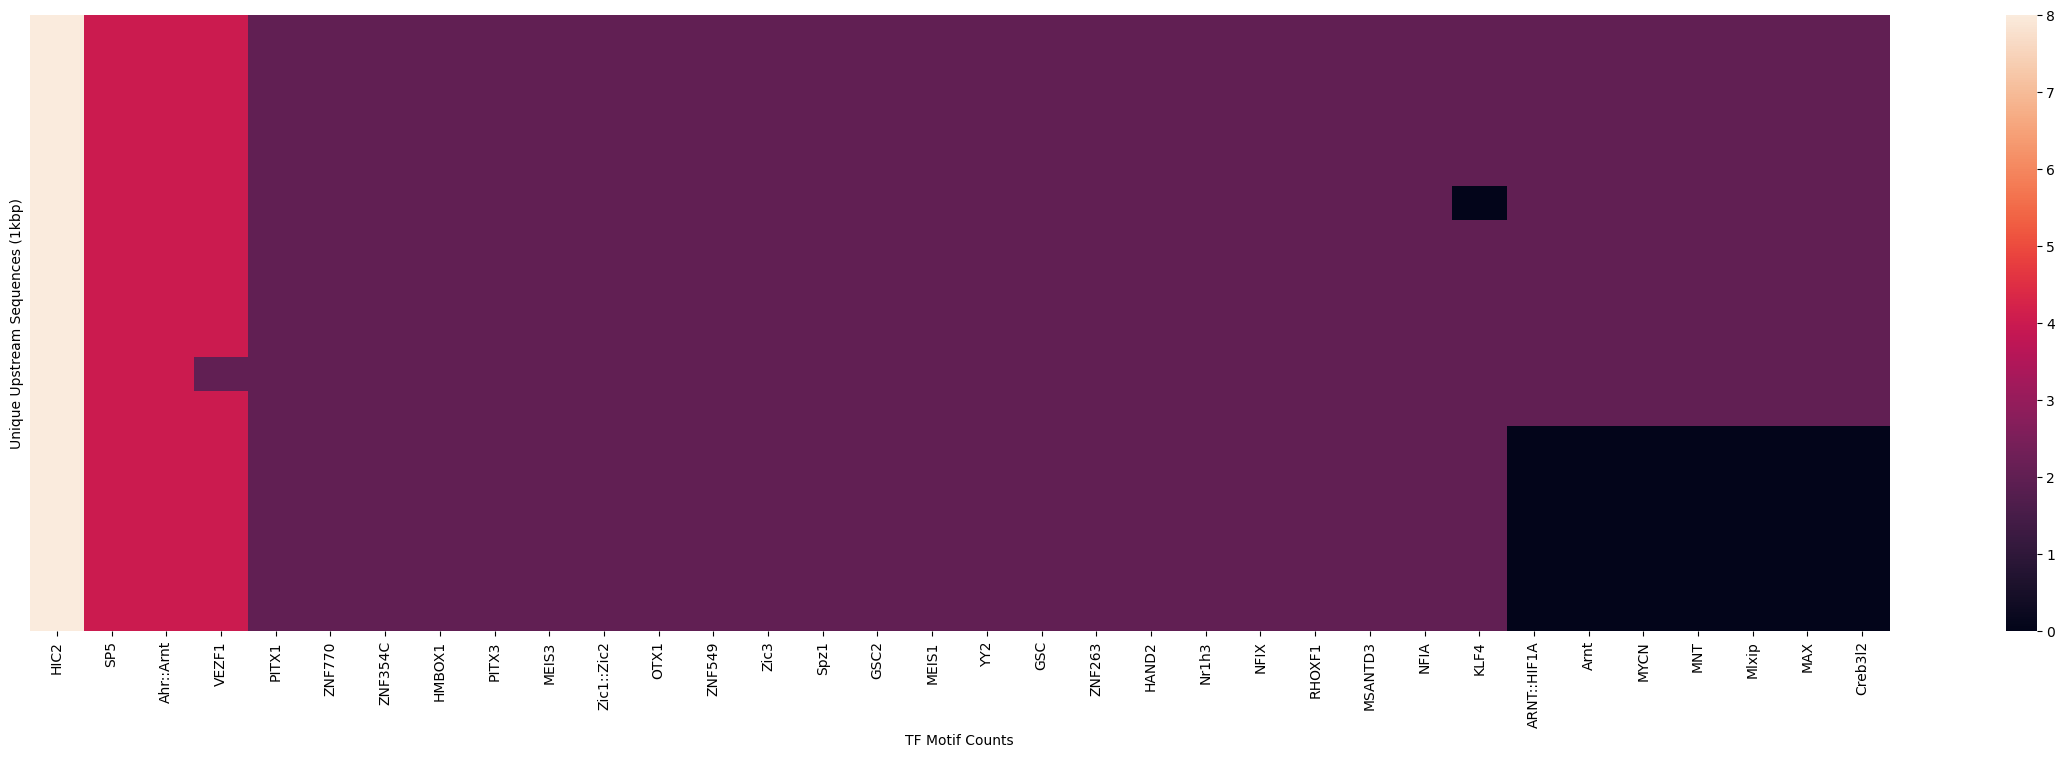

In [37]:
import seaborn as sns
plt.figure(figsize=(30, 8))
ax=sns.heatmap(sortedPromoterDF3_sorted)
ax.set_yticks([])    
plt.ylabel('Unique Upstream Sequences (1kbp)')
plt.xlabel('TF Motif Counts')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_TF_Motif_Heatmap.pdf", dpi=300, bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_TF_Motif_Heatmap.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [38]:
sortedPromoterDF3_sorted

motif,HIC2,SP5,Ahr::Arnt,VEZF1,PITX1,ZNF770,ZNF354C,HMBOX1,PITX3,MEIS3,...,MSANTD3,NFIA,KLF4,ARNT::HIF1A,Arnt,MYCN,MNT,Mlxip,MAX,Creb3l2
promoter,,,,,,,,,,,,,,,,,,,,,
SeqPromoter:1,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:16,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:13,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:10,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:8,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:7,8,4,4,4,2,2,2,2,2,2,...,2,2,0,2,2,2,2,2,2,2
SeqPromoter:9,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:5,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
SeqPromoter:4,8,4,4,4,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


## Biological Differences (GO terms etc.)

In [39]:
def splitList(inputList):

    newList=[]
    for x in inputList:
        if '::' in x:
            newList.append(x.split("::")[0])
            newList.append(x.split("::")[1])
        else:
            newList.append(x)
    return(newList)

In [40]:
from mygene import MyGeneInfo
mg = MyGeneInfo()
cluster0 = splitList(tops[0].index)
cluster1 = splitList(tops[1].index)

q0 = mg.querymany(cluster0, scopes="symbol", fields="go", species="human")
q1 = mg.querymany(cluster1, scopes="symbol", fields="go", species="human")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [41]:
def returnTerms(records):
    terms = set()
    for rec in records:
        for item in rec.get('go', {}).get('BP', []):
            if isinstance(item, dict) and 'term' in item:
                terms.add(item['term'])
    return terms

In [42]:
#drive angiogenic/hypoxic programs (VEGF axis, endothelial migration/proliferation),
#coordinate stress responses (ROS/ER stress, survival vs apoptosis, senescence),
#and control mesenchymal differentiation/ECM remodeling (cartilage/bone/EMT),
#embryonic development and tissue repair (and frequently implicated in tumor-like states

returnTerms(q0)

{'DNA damage response, signal transduction by p53 class mediator',
 'apoptotic process',
 'astrocyte differentiation',
 'axonal transport of mitochondrion',
 'cartilage development',
 'cell differentiation',
 'cell division',
 'cellular response to dexamethasone stimulus',
 'cellular response to glucocorticoid stimulus',
 'cellular response to hypoxia',
 'cellular response to interleukin-1',
 'cellular response to oxidative stress',
 'cellular response to steroid hormone stimulus',
 'cellular response to transforming growth factor beta stimulus',
 'cellular response to virus',
 'chondrocyte differentiation',
 'chromatin organization',
 'chromosome segregation',
 'collagen metabolic process',
 'connective tissue replacement involved in inflammatory response wound healing',
 'elastin metabolic process',
 'endoplasmic reticulum to Golgi vesicle-mediated transport',
 'epithelial to mesenchymal transition',
 'glucose homeostasis',
 'heterochromatin formation',
 'host-mediated activation of 

In [43]:
#“Stress-responsive, hormone-regulated differentiation/checkpoint TFs”
#with particular enrichment for epithelial/skin barrier and testis (Sertoli/germline) developmental programs, coupled to UPR/ISR and G1/S control.
returnTerms(q1)

{'DNA damage response',
 'DNA repair',
 'DNA-templated transcription',
 'MAPK cascade',
 'SMAD protein signal transduction',
 'anterior/posterior axis specification, embryo',
 'autophagy',
 'canonical Wnt signaling pathway',
 'cell differentiation',
 'cellular defense response',
 'cellular response to BMP stimulus',
 'cellular response to cadmium ion',
 'cellular response to copper ion',
 'cellular response to diamide',
 'cellular response to endothelin',
 'cellular response to epidermal growth factor stimulus',
 'cellular response to fatty acid',
 'cellular response to gamma radiation',
 'cellular response to growth factor stimulus',
 'cellular response to heat',
 'cellular response to hormone stimulus',
 'cellular response to hydrogen peroxide',
 'cellular response to hypoxia',
 'cellular response to laminar fluid shear stress',
 'cellular response to parathyroid hormone stimulus',
 'cellular response to phorbol 13-acetate 12-myristate',
 'cellular response to polyamine macromolecule

## How do the network clusters of amino acids look compared to these upstream motifs

In [53]:
copyUpstreamMotifGroups={}
for name,sequence in uniquePromoters2.items():
    copyUpstreamMotifGroups[name] = {'SequenceCluster':uniquePromotersNames[sequence],'cluster':res.at[uniquePromotersNames[sequence], 'cluster'], 'color':ColorDictionary[name][0]}

In [54]:
clusterNetworkDF = pd.DataFrame(data=copyUpstreamMotifGroups).T

In [56]:
#clusterNetworkDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings_wSeqeunceCluster.csv")

In [47]:
clusterNetworkDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings.csv")

In [48]:
clusterNetworkDF[clusterNetworkDF['Unnamed: 0'].str.contains("NA18989")]

,Unnamed: 0,cluster,color
940,NA18989_chrY:22862797-22877246,0,#ff7f00
941,NA18989_chrY:22886338-22900783,0,#ff7f00
942,NA18989_chrY:22909875-22924324,0,#e31a1c
943,NA18989_chrY:22933416-22947865,0,#e31a1c
944,NA18989_chrY:22956957-22971407,0,#ff7f00
945,NA18989_chrY:23262423-23276873,0,#33a02c
946,NA18989_chrY:23285965-23300407,0,#33a02c
947,NA18989_chrY:24369544-24383994,1,#1f78b4
948,NA18989_chrY:24604458-24618900,1,#1f78b4


In [42]:
#coordinates stage-specific isoforms in both intrinsic germline programs (Cluster 1) 
#and the extrinsic metabolic/vascular/secretory support (Cluster 2) that the germline depends on.

In [52]:
import collections
collections.Counter(clusterNetworkDF['cluster'])

Counter({np.int32(0): 787, np.int32(1): 251})

In [45]:
#clusterNetworkDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/RBMY_Plus_Flanking/RBMY_Upstream_Motif_Groupings.csv")

In [46]:
import seaborn as sns
# build contingency
co = (clusterNetworkDF.groupby(["cluster","color"]).size()
        .unstack("color", fill_value=0).sort_index())

# counts
#sns.heatmap(co, annot=False, fmt="d", cmap="mako")
#plt.title("Cluster × Color (counts)"); plt.xlabel("Color"); plt.ylabel("Cluster"); plt.show()

# row-normalized (%) highlights color composition per cluster
row_pct = co.div(co.sum(axis=1), axis=0).mul(100)
#sns.heatmap(row_pct, annot=False, fmt=".1f", cmap="mako", vmin=0, vmax=100, cbar_kws={"label":"% per cluster"})
#plt.title("Cluster × Color (% of cluster)"); plt.show()

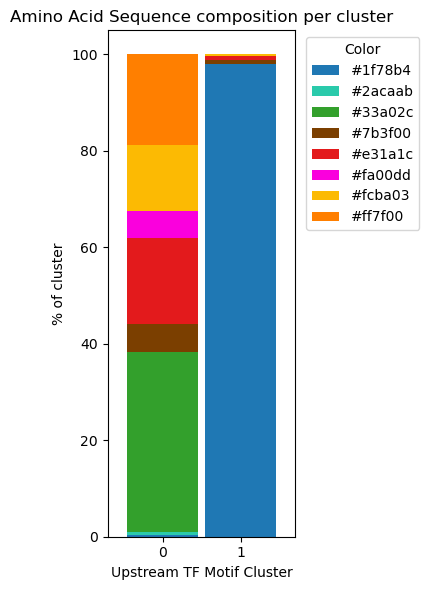

In [48]:
row_pct.plot(kind="bar", stacked=True, figsize=(4,6), width=0.9, color=row_pct.columns)
plt.ylabel("% of cluster")
plt.xticks(rotation=0)
plt.xlabel("Upstream TF Motif Cluster", rotation=0) 
plt.legend(title="Color", bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Amino Acid Sequence composition per cluster")
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_TF_Motif_wAminoAcidClusers.pdf", dpi=300, bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/RBMY/RBMY_Submission/RBMY_Upstream_TF_Motif_wAminoAcidClusers.jpg", dpi=300, bbox_inches='tight')
plt.show()